# 4.1.3 从吸引状态到吸引集合

## 学习目标与先修知识

能用不变性、点到集合的距离与吸引域（basin of attraction）区分吸引平衡（equilibrium）、周期吸引和不吸引的中心。

先修：4.1.1—4.1.2 的相线（phase line）、解析轨迹（trajectory）和初值（initial condition）扫描；第 3 篇的二维状态（state）。

## 具体问题

生命节律受到小扰动后可以恢复振幅（amplitude），但峰值时间仍偏移。这样的“恢复”应当要求回到一个点，还是回到一条运动轨道？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
points=np.array([[1,0],[0,1],[.6,.8],[2,0]])
print("到原点的距离：",np.linalg.norm(points,axis=1))
print("到单位圆的距离：",abs(np.linalg.norm(points,axis=1)-1))

到原点的距离： [1. 1. 1. 2.]
到单位圆的距离： [0. 0. 0. 1.]


## 模型假设

以二维活动偏差 (x,y) 表示两个变量；时间 τ 与状态无量纲（dimensionless）。先用纯旋转作反例，再用仅规定径向恢复的圆周运动作机制示意。它们不是任何器官节律的参数（parameter）标定，也未加入外界驱动或噪声。

## 数学解释与推导

点到集合 $A$ 的距离定义为 $d(x,A)=\inf_{a\in A}\|x-a\|$。原点的距离是半径 $r$；单位圆的距离是 $|r-1|$，不是到固定点（fixed point） (1,0) 的距离。

**不变集（invariant set）**表示从集合内出发仍留在集合内；对本节可逆流的完整不变性要求 $\Phi_t(A)=A$。这里采用稳定吸引子（attractor）的常用充分定义：A 非空、紧、不变，存在邻域使轨迹到 A 的距离趋零，并且它作为集合具有 Lyapunov 稳定性（起步足够近就始终足够近）。更一般的弱吸引定义留在拓展。吸引域由所有趋近 A 的初值组成，通常不是 A 本身。

纯旋转 x′=−y、y′=x 满足 $(x²+y²)'=0$。每条圆是不变集，但半径 1.1 的轨迹到单位圆始终相距 0.1，因此单位圆不吸引邻域。再定义 r′=r(1−r²)、θ′=1，r>0。令 s=r²，得 s′=2s(1−s)，沿上一节的倒数替换可解出
$$r(t)=\left[1+(r_0^{-2}-1)e^{-2t}\right]^{-1/2},\qquad \theta(t)=t+\theta_0.$$
所有非零半径趋于 1，故单位圆吸引平面除原点外的初值。r=0 是另一个不变解，不属于这个吸引域。圆内外流向指向圆也给出集合稳定性。两个相位（phase）相差 Δθ 的解即使都落在圆上，同一时刻点间距离仍为 $2|\sin(\Delta\theta/2)|$。恢复振幅与恢复相位不能混为一谈。

## 核心实现

把推导逐步写成函数；不以黑箱轨迹代替方程。

In [3]:
def attracting_circle(radius, phase, times):
    times=np.asarray(times)
    r=np.zeros_like(times) if radius==0 else 1/np.sqrt(1+(radius**-2-1)*np.exp(-2*times))
    return np.column_stack([r*np.cos(times+phase),r*np.sin(times+phase)])

## 对照实验

C:\Users\10149\AppData\Local\Temp\ipykernel_15264\4053960719.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


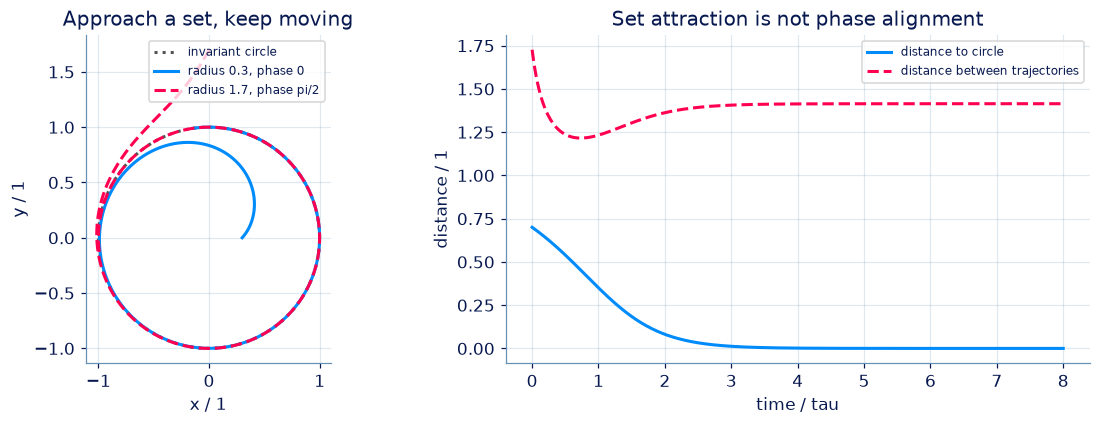

In [4]:
times=np.linspace(0,8,401)
first=attracting_circle(.3,0,times); second=attracting_circle(1.7,math.pi/2,times)
fig,axes=plt.subplots(1,2,figsize=(11,4))
theta=np.linspace(0,2*math.pi,300)
axes[0].plot(np.cos(theta),np.sin(theta),':',color=GRAY,label='invariant circle')
axes[0].plot(*first.T,color=BLUE,label='radius 0.3, phase 0')
axes[0].plot(*second.T,'--',color=PINK,label='radius 1.7, phase pi/2')
axes[0].set(xlabel='x / 1',ylabel='y / 1',title='Approach a set, keep moving');axes[0].set_aspect('equal')
axes[1].plot(times,abs(np.linalg.norm(first,axis=1)-1),color=BLUE,label='distance to circle')
axes[1].plot(times,np.linalg.norm(first-second,axis=1),'--',color=PINK,label='distance between trajectories')
axes[1].set(xlabel='time / tau',ylabel='distance / 1',title='Set attraction is not phase alignment')
for ax in axes:ax.legend(fontsize=8)
fig.tight_layout();plt.show()

## 结果解释

左图两条轨迹趋近整个单位圆，右图到圆的距离趋近零，但两轨迹的距离趋近 √2。对照纯旋转可见，是否形成闭轨道与是否吸引邻近状态是两个问题：前者看轨道形状，后者看邻近轨迹到它的距离。

### 独立核对

In [5]:
assert np.all(attracting_circle(0,0,times)==0)
assert abs(np.linalg.norm(first[-1])-1)<1e-6
assert abs(np.linalg.norm(first[-1]-second[-1])-math.sqrt(2))<1e-6
assert np.allclose(np.hypot(1.1*np.cos(times),1.1*np.sin(times))-1,.1)
print('零初值、距离极限与纯旋转反例一致。')

零初值、距离极限与纯旋转反例一致。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：吸引的是点还是集合

对 r′=r(1−r²)、θ′=1，r>0。哪些陈述成立？

- **A.** 单位圆是不变集（invariant set），邻近轨迹（trajectory）到单位圆的距离趋于零。
- **B.** 所有轨迹最终在单位圆上同一点停下。
- **C.** 吸引域（basin of attraction）包含所有 r>0 的初值（initial condition），原点例外。
- **D.** 一条被画出的圆必然吸引邻近初值。

[作答：吸引的是点还是集合](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-attractor-set)

### 第 2 题 · 单项选择题：不变为何不一定吸引

纯旋转 x′=−y、y′=x 的单位圆有什么性质？

- **A.** 它不变，但半径 1.1 的轨迹（trajectory）到它的距离始终 0.1。
- **B.** 它吸引整个平面。
- **C.** 圆上运动就说明混沌（chaos）。
- **D.** 平衡（equilibrium）点是唯一可能的吸引子（attractor）。

[作答：不变为何不一定吸引](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-center-counterexample)

### 第 3 题 · Python 计算题：计算点到圆和点的距离

对每个二维状态（state），分别计算到原点和到半径 radius 圆周的欧氏距离。

**函数与代码模板**

```python
def solve(
    points: list[list[float]],
    radius: float,
) -> tuple[list[float], list[float]]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `points` | `list[list[float]]` | 二维状态 [x,y] 列表。 | 1 |
| `radius` | `float` | 圆的半径。 | 1 |

**返回值**

按以下顺序返回元组：(to_origin, to_circle)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `to_origin` | `list[float]` | 逐点到原点的距离。 | 1 |
| `to_circle` | `list[float]` | 逐点到整个圆周的最小距离。 | 1 |

**计算规则**

逐点计算 r=sqrt(x²+y²)，返回 (r 列表, |r−radius| 列表)。距离到集合不同于距离到某个选定圆周点。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 1—50 个二维点；各坐标在 [−10,10]；0<radius≤5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| points | 二维状态 [x,y] 列表。 | [[3, 4], [0, 0], [0, 1]] | 1 |
| radius | 圆的半径。 | 1 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
points = [[3, 4], [0, 0], [0, 1]]
radius = 1

result = solve(points, radius)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| to_origin | 逐点到原点的距离。 | [5.0, 0.0, 1.0] | 1 |
| to_circle | 逐点到整个圆周的最小距离。 | [4.0, 1.0, 0.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([5.0, 0.0, 1.0], [4.0, 1.0, 0.0])
```

**样例解释**

点 (3,4) 的半径是 5，到单位圆的距离是 4；原点到单位圆的距离是 1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：计算点到圆和点的距离](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-distance-circle)

### 第 4 题 · Python 计算题：计算到有限平衡集合的距离

在一维状态（state）轴上，给定候选平衡（equilibrium）点集合。对每个观测（observation）状态返回它到这个集合的最短距离；不据距离大小自动判断吸引性。

**函数与代码模板**

```python
def solve(
    states: list[float],
    equilibria: list[float],
) -> list[float]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 观测状态，按输入（input）顺序保留。 | 1 |
| `equilibria` | `list[float]` | 给定非空平衡点集合。 | 1 |

**返回值**

直接返回 distances（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `distances` | `list[float]` | 每个状态到给定集合的最短距离。 | 1 |

**计算规则**

对每个 x 返回 min(abs(x-a) for a in equilibria)。平衡点顺序及重复值不改变距离；只返回距离列表。

**约束与边界**

- 所有数值有限，不修改输入列表。
- states 长度 1—50，equilibria 长度 1—10；所有数值在 [−10,10]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | 观测状态，按输入（input）顺序保留。 | [-2, 0, 0.5, 1] | 1 |
| equilibria | 给定非空平衡点集合。 | [-1, 1] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [-2, 0, 0.5, 1]
equilibria = [-1, 1]

result = solve(states, equilibria)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| distances | 每个状态到给定集合的最短距离。 | [1, 1, 0.5, 0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1, 1, 0.5, 0]
```

**样例解释**

状态 −2 到 −1 最近，距离 1；0 到两个平衡点都相距 1；0.5 到 1 相距 0.5；1 已在集合内。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：计算到有限平衡集合的距离](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-distance-equilibria)

### 参考阅读

[MIT 非线性动力学讲义](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/pages/lecture-notes/)：第 15—16 讲的截面，第 19 讲的奇异几何，第 20—21 讲的 Lorenz 方程，第 24 讲的增长率。核心推导与实验均已写在本节。